## Домашнее задание 4

### Problem 1: The impact of the parameters on the cost and on the state-action trajectory

Now let us perform a series of experiments with varying the parameters and the values in the $Q$ and $R$ matrices. But first, let us wrap the whole simulation in a single function for convenience.

Copy the necessary code from the seminar.

In [1]:
import numpy as np
import cv2
import math
import copy
import matplotlib.pyplot as plt
from scipy import linalg

def plot_1d(data, xlabel = "timestamp", ylabel = ""):
    plt.figure(figsize=(7, 4))
    plt.plot(data)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

from matplotlib.animation import FuncAnimation
import math
from matplotlib import rc
rc('animation', html='jshtml')

def animate(trajectory, axes_limits=[-5, 5, -5, 5], frames = 50, step = 1):
    x_hist_, y_hist_, _ = trajectory

    x_hist = x_hist_[::step]
    y_hist = y_hist_[::step]

    plt.ioff()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis(axes_limits)
    ax.set_aspect("equal")

    point1, = ax.plot(0,1, marker="o", label="location")
    ax.legend()
    ax.grid()
    ax.set_xlabel("$x$")

    def update(t):
        x = x_hist[int(t) % len(x_hist)]

        point1.set_data([x],[0])

        return point1,

    ani = FuncAnimation(fig, update, interval=1000/24, blit=True, repeat=True,
                    frames=frames)
    plt.ion()

    return ani

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Dyn_block_1D:
    def __init__(self, A, B, x0, v0, dt):
        self.x = np.array([[x0], [v0]])

        self.m = m
        self.dt = dt

        self.A = A

        self.B = B

    def sys_dyn(self, u):
        xdot = self.A @ self.x + self.B @ u

        return xdot

    def integrate(self, xdot):
        self.x += xdot * self.dt

    def get_state(self):
        return self.x

def run_block_simulation(A, B, x0, v0, dt, num_episodes, control_function):
    block = Dyn_block_1D(A, B, x0, v0, dt)

    x_traj = []
    v_traj = []
    u_traj = []

    for i in range(num_episodes):
        x = block.get_state()

        control = control_function(i, x)

        x_traj.append(x[0, 0])
        v_traj.append(x[1, 0])
        u_traj.append(control)

        x_dot = block.sys_dyn(np.array([[control]]))

        block.integrate(x_dot)

    return x_traj, v_traj, u_traj

def run_and_visualize_block(A, B, x0, v0, dt, num_episodes, control_function):
    x_hist, v_hist, u_hist = run_block_simulation(A = A, B = B, x0 = x0, v0 = v0, dt = dt,
                        num_episodes = num_episodes, control_function = control_function)

    plot_1d(x_hist, ylabel = "p")
    plot_1d(v_hist, ylabel = "p_dot")
    plot_1d(u_hist, ylabel = "control_force")

    plt.figure(figsize=(5, 3))
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.plot(x_hist, v_hist)
    plt.xlabel("p")
    plt.ylabel("p_dot")

    plt.show()

    return (x_hist, v_hist, u_hist)

In [3]:
def run_visualize_evaluate_LQR_controller(A, B, Q_multiplier, R_multiplier, num_episodes,
                                          dt, x0, v0):
    Q = np.array([[1, 0],
                  [0, 1]]) * Q_multiplier

    R = np.eye(1) * R_multiplier

    P = linalg.solve_continuous_are(A, B, Q, R)

    # INSERT YOUR CODE FROM ABOVE HERE

    K = np.linalg.inv(R) @ B.T @ P

    # INSERT YOUR CODE FROM ABOVE HERE

    print(K)

    def LQR_control(i, x):
        K = np.linalg.inv(R) @ B.T @ P

        u = - K @ x

        return u[0, 0]

    control_function = LQR_control

    trajectory = run_and_visualize_block(A = A, B = B, x0 = x0, v0 = v0, dt = dt,
                      num_episodes = num_episodes, control_function = control_function)

    traj_cost = evaluate_state_action_trajectory(trajectory, Q, R, dt)

    print(traj_cost)

In [4]:
R_m = 0.01
R_ = np.eye(1) * R_m

np.linalg.inv(R_)

array([[100.]])

In [5]:
def evaluate_state_action_trajectory(trajectory, Q, R, dt):
    xtr, vtr, utr = trajectory

    cost = 0

    for i in range(len(xtr)):
        xvec = np.array([[xtr[i]],
                         [vtr[i]]])

        uvec = np.array([[utr[i]]])

        # YOUR CODE BELOW

        curr_cost = (xvec.T @ Q @ xvec + uvec.T @ R @ uvec) * dt 

        # YOUR CODE ABOVE

        cost += curr_cost

    return cost

[[1.         1.73205081]]


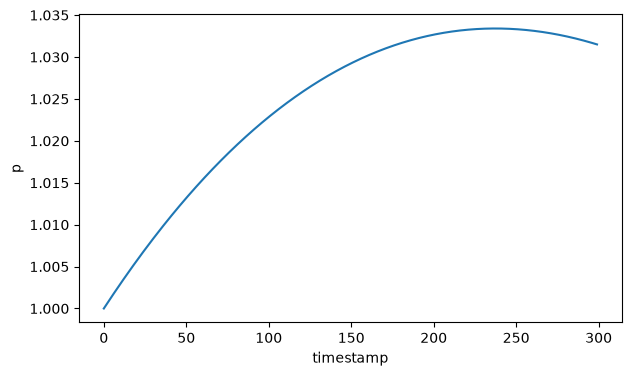

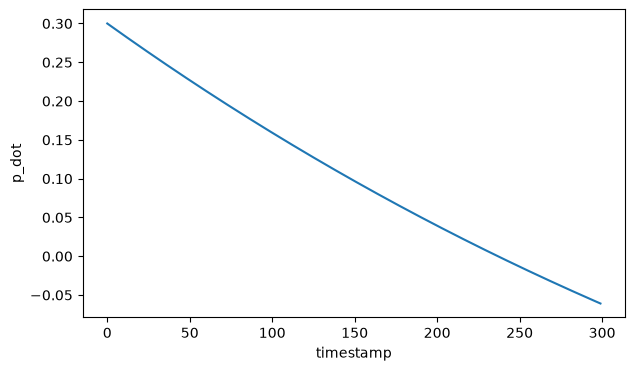

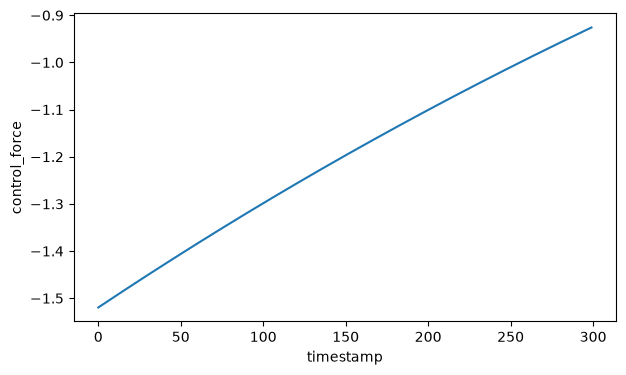

<Figure size 500x300 with 0 Axes>

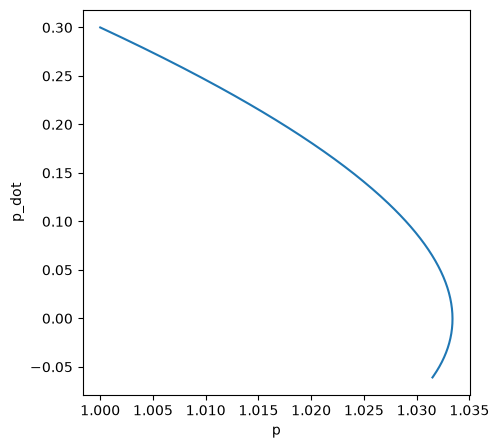

[[0.76694758]]


In [11]:
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])

m  = 1.0

B = np.array([[0],
              [1 / m]])

num_episodes = 300

x0 = 1.0
v0 = 0.3

dt = 0.001

run_visualize_evaluate_LQR_controller(A = A, B = B, Q_multiplier = 1, R_multiplier = 1,
                                      num_episodes = num_episodes, dt = dt, x0 = x0, v0 = v0)

Try changing the simulation parameters and answer the following questions:
- Does the increase of the number of the simulation steps from $300$ to $1300$ change the total cost? Why so?
- Does the increase of the number of the simulation steps from $1300$ to $13000$ change the total cost? Why so?

Now please set the number of simulation steps to $3000$.

- How does the change of the time step $\Delta t$ from $0.01$ to $0.001$ along with a proper increase in the number of the simulation steps (in order to conserve the total duration of the episode) change the total cost? How exactly?
- Try setting R_multiplier to $0.1$. What happened to the system trajectory? What happened to the gain matrix?

# Ответ

$$n_{ep} = 300$$
$$J = 10.80270728$$

Это бейслайн. Длительность симуляции короткая, стоимость слишком высокая чтобы система сошлась так быстро.

$$n_{ep} = 1300$$
$$J = 14.70159505$$

Стоимость увеличилась потому что система проделала бОльший путь и в итоге сошлась.

$$n_{ep} = 13000$$
$$J = 14.74016674$$

Стоимость не сильно увеличилась так как система быстро сошлась и находилась в окрестности точки длительное время

$$dt=0.01, n_{ep} = 3000: J = 14.7401508$$
$$dt=0.001, n_{ep} = 30000: J = 14.71019844$$

Стоимость немного уменьшилась, так как уменьшенная дискретизация позволила более точно вести управление без лишней инерции которую надо компенсировать.

При уменьшении множителя $R = 0.1$ система стала значительно менее инертная, так как стоимость управления снизилась, и она может позволить себе больше  вкладываться в "манёвры", что и позволяет с лёгкостью нивелировать инерцию. Члены матрицы коэффициентов усиления увеличились,  так как $R^{-1}$  стала больше

### Problem 2: Spring-mass system

Now let us connect the mass to the wall with a spring of stifness $k$. This will change the $A$ matrix to the following:

$A =
\begin{pmatrix}
0 & 1 \\
-\frac{k}{m} & 0
\end{pmatrix}$

Try different values of $Q$ and $R$ matrices:
- Default values of $1$ and $1$
- With very expensive control
- With very cheap control

Examine the results and describe them.

# Ответ

При $Q = 1$

$R = 1$ - сходится достаточно быстро

$R = 100$ - Из-за высокой стоимости система с трудом компенсирует перегибы по управлению. Колебания затухают, но система не успевает стабилизироваться за время симуляции

$R = 0.01$ - система сходится очень быстро

При $Q = 100$

$R = 1$ - сходится быстро

$R = 100$ - сходится быстро, но с "переруливанием" которое быстро затухает

$R = 0.01$ - сходится быстро


При $Q = 0.01$

$R = 1$ - затухающие колебания, система не успевает сойтись за время симуляции

$R = 100$ - издалека выглядит как гармонические колебания, система очень долго будет сходиться

$R = 0.01$ - быстро сходится с небольшим переруливанием

## Выводы

Если $Q$ низкое, то система "не мотивирована" для того чтобы сходиться. При ощутимом по величине $Q$ скорость сходимости системы зависит от дешевизны $R$ - чем дешевле, тем быстрее

[[0.41421356 1.35219345]]


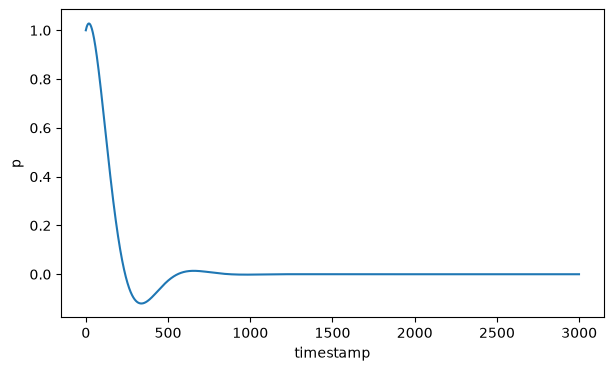

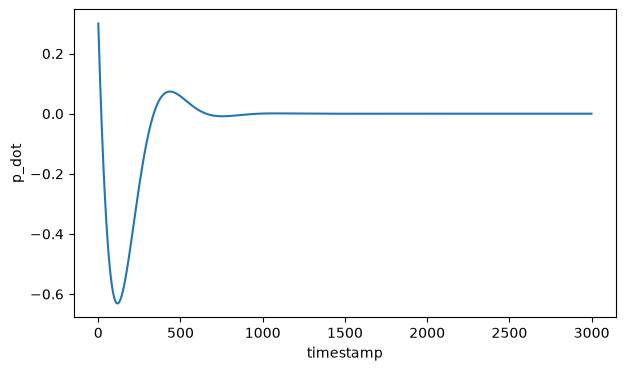

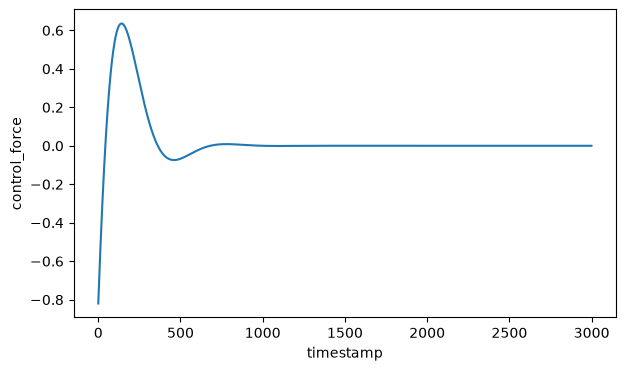

<Figure size 500x300 with 0 Axes>

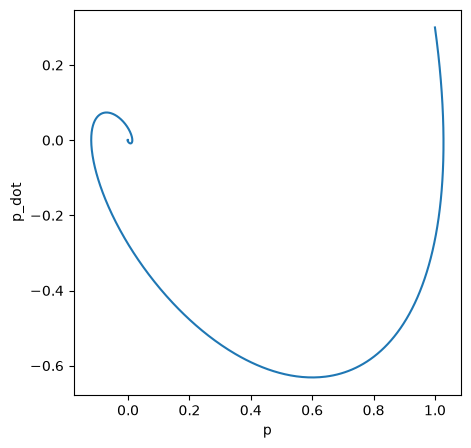

[[0.02310326]]


In [18]:
m  = 1.0
k = 1.0

A = np.array([[0.0, 1.0],
              [- k / m, 0.0]])

B = np.array([[0],
              [1 / m]])

num_episodes = 3000

x0 = 1.0
v0 = 0.3

dt = 0.01

run_visualize_evaluate_LQR_controller(A = A, B = B, Q_multiplier = 0.01, R_multiplier = 0.01,
                                      num_episodes = num_episodes, dt = dt, x0 = x0, v0 = v0)